# Python Data Analysis

---

## 📚 Table of Contents
1. [Python Fundamentals](#1-python-fundamentals) — List comprehensions, lambda, map/filter
2. [Generators & Iterators](#2-generators--iterators) — yield, generator expressions, enumerate, zip
3. [NumPy Basics](#3-numpy-basics) — Arrays, vectorization, dtypes
4. [Pandas — Slicing & Dicing](#4-pandas--slicing-and-dicing) — loc, iloc, filtering, columns
5. [Dates & Strings](#5-dates--strings) — .dt accessor, .str methods, regex
6. [Data Cleaning Essentials](#6-data-cleaning-essentials) — Nulls, deduplication, type casting
7. [GroupBy & Aggregations](#7-groupby--aggregations) — agg, pivot_table, merge/join
8. [Exploratory Data Analysis (EDA)](#8-exploratory-data-analysis-eda) — Workflow & checklist
9. [Visualization — Matplotlib & Seaborn](#9-visualization--matplotlib--seaborn) — All chart types
10. [Basic Statistics](#10-basic-statistics) — Mean, median, outliers, correlation
11. [SQL Basics](#11-sql-basics) — Queries, joins, SQL from Python

---
Modify values and experiment — that's the best way to learn.

In [1]:
# ============================================================
# SETUP — Run this cell first before anything else
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='Set2')

print('✅ All libraries loaded successfully!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ All libraries loaded successfully!
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


---
## 1. Python Fundamentals
These are building blocks you will use every single day. Master these before moving on to libraries.

### 1.1 List Comprehensions
List comprehensions create lists in a **single readable line** instead of a for-loop + append.
They are faster to write, faster to execute, and easier to read.

**Syntax:** `[expression  for  item  in  iterable  if  condition]`

In [2]:
# ── 1. Square numbers 1-10 ──────────────────────────────────
squares = [x**2 for x in range(1, 11)]
print('Squares:', squares)

# ── 2. Filter even numbers only ────────────────────────────
evens = [x for x in range(20) if x % 2 == 0]
print('Evens:', evens)

# ── 3. Clean a list of messy strings ───────────────────────
raw   = ['  Alice ', 'BOB  ', ' carol', '  DAVE']
clean = [s.strip().title() for s in raw]
print('Clean names:', clean)

# ── 4. Extract a field from a list of dicts ────────────────
students = [
    {'name': 'Alice', 'score': 85},
    {'name': 'Bob',   'score': 92},
    {'name': 'Carol', 'score': 78}
]
names  = [s['name']  for s in students]
passed = [s['name']  for s in students if s['score'] >= 80]
print('All students:', names)
print('Passed (>=80):', passed)

# ── 5. Speed comparison ─────────────────────────────────────
import time

N = 1_000_000

t0 = time.time()
result_loop = []
for x in range(N):
    result_loop.append(x**2)
t1 = time.time()

result_comp = [x**2 for x in range(N)]
t2 = time.time()

print(f'\nfor-loop:           {(t1-t0)*1000:.1f} ms')
print(f'list comprehension: {(t2-t1)*1000:.1f} ms')

Squares: [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
Evens: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Clean names: ['Alice', 'Bob', 'Carol', 'Dave']
All students: ['Alice', 'Bob', 'Carol']
Passed (>=80): ['Alice', 'Bob']

for-loop:           144.6 ms
list comprehension: 82.9 ms


### 1.2 Lambda Functions
A **lambda** is a small, anonymous, single-line function. Use it when you need a quick function
without naming it — most commonly inside `sorted()`, `map()`, `filter()`, or pandas `.apply()`.

**Syntax:** `lambda arguments: expression`

In [3]:
# ── 1. Sort a list of tuples by the second element ─────────
data = [('Alice', 85), ('Bob', 92), ('Carol', 78), ('Dave', 95)]
by_score = sorted(data, key=lambda x: x[1], reverse=True)
print('Ranked by score:', by_score)

# ── 2. Apply a tax rate to prices ──────────────────────────
prices   = [100, 200, 350, 499]
with_tax = list(map(lambda p: round(p * 1.18, 2), prices))
print('\nPrices with 18% tax:', with_tax)

# ── 3. Filter negative values ──────────────────────────────
values    = [-3, 7, -1, 0, 5, -8, 12]
positives = list(filter(lambda x: x >= 0, values))
print('\nNon-negative values:', positives)

# ── 4. pandas apply() — classify salary column ─────────────
df_sal = pd.DataFrame({
    'name':   ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'salary': [75000, 82000, 55000, 91000, 62000]
})
df_sal['band'] = df_sal['salary'].apply(lambda x: 'High' if x > 75000 else 'Standard')
print('\nSalary bands:')
print(df_sal)

Ranked by score: [('Dave', 95), ('Bob', 92), ('Alice', 85), ('Carol', 78)]

Prices with 18% tax: [118.0, 236.0, 413.0, 588.82]

Non-negative values: [7, 0, 5, 12]

Salary bands:
    name  salary      band
0  Alice   75000  Standard
1    Bob   82000      High
2  Carol   55000  Standard
3   Dave   91000      High
4    Eve   62000  Standard


### 1.3 map() and filter()
Functional programming tools that apply a function to every item in an iterable.
They return **lazy iterators** — wrap with `list()` to see the results.

In modern Python, list comprehensions often replace them, but you'll encounter them in existing codebases.

In [4]:
nums = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# map(): apply function to every element
doubled = list(map(lambda x: x * 2, nums))
print('Doubled:', doubled)

# filter(): keep elements where function returns True
evens = list(filter(lambda x: x % 2 == 0, nums))
print('Evens:', evens)

# Combining map + filter
# "Double all even numbers" — two approaches:

# Approach A: map + filter (traditional)
result_a = list(map(lambda x: x*2, filter(lambda x: x%2==0, nums)))

# Approach B: list comprehension (preferred)
result_b = [x*2 for x in nums if x % 2 == 0]

print('Doubled evens (map+filter):', result_a)
print('Doubled evens (list comp): ', result_b)
print('Same result?', result_a == result_b)

Doubled: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Evens: [2, 4, 6, 8, 10]
Doubled evens (map+filter): [4, 8, 12, 16, 20]
Doubled evens (list comp):  [4, 8, 12, 16, 20]
Same result? True


---
## 2. Generators & Iterators
Generators allow you to process data **lazily** — one item at a time — instead of loading everything into memory at once.
This is critical when working with large datasets or files.

### 2.1 What is an Iterator?
An iterator is an object with `__iter__()` and `__next__()`. Python's `for`-loop repeatedly calls `next()` until `StopIteration` is raised.

In [5]:
# A list is iterable but not itself an iterator
my_list = [10, 20, 30]
it = iter(my_list)   # create an iterator from the list

print(next(it))   # 10
print(next(it))   # 20
print(next(it))   # 30
# next(it) would now raise StopIteration

# For-loop is just syntactic sugar for this:
print('\nFor-loop does the same thing:')
for item in [10, 20, 30]:
    print(item)

10
20
30

For-loop does the same thing:
10
20
30


### 2.2 Generator Functions (yield)
A generator function uses `yield` instead of `return`. Each call to `next()` resumes from where it paused.

**Key benefit:** Only the *current item* is ever in memory — perfect for huge datasets.

In [6]:
import sys

# ── Regular function — builds entire list ──────────────────
def get_squares_list(n):
    return [x**2 for x in range(n)]

# ── Generator function — yields one item at a time ─────────
def get_squares_gen(n):
    for x in range(n):
        yield x**2

N = 100_000

lst = get_squares_list(N)
gen = get_squares_gen(N)

print(f'List size in memory: {sys.getsizeof(lst):>10,} bytes')
print(f'Gen  size in memory: {sys.getsizeof(gen):>10,} bytes')
print(f'Memory saved: {sys.getsizeof(lst) / sys.getsizeof(gen):.0f}x !!')

# ── Practical example: process data row by row ─────────────
def generate_sales_data(n):
    """Simulates reading rows from a large file one by one."""
    import random
    departments = ['Sales', 'IT', 'HR', 'Finance']
    for i in range(n):
        yield {
            'id':         i,
            'department': random.choice(departments),
            'amount':     round(random.uniform(100, 5000), 2)
        }

# Process 1 million rows without loading them all into memory
total = 0
count = 0
for row in generate_sales_data(1_000_000):
    total += row['amount']
    count += 1

print(f'\nProcessed {count:,} rows. Total amount: ${total:,.2f}')

List size in memory:    800,984 bytes
Gen  size in memory:        200 bytes
Memory saved: 4005x !!

Processed 1,000,000 rows. Total amount: $2,546,860,541.20


### 2.3 Generator Expressions
Like a list comprehension but with `()` instead of `[]`. Lazy — items computed on demand.

In [7]:
# List comprehension — stores ALL results immediately
squares_list = [x**2 for x in range(10)]      # list: all 10 numbers in memory

# Generator expression — computes each item when needed
squares_gen  = (x**2 for x in range(10))      # generator: almost no memory used

print('List:', squares_list)
print('Gen first item:', next(squares_gen))
print('Gen second item:', next(squares_gen))

# Very common pattern: sum without ever building a list
total = sum(x**2 for x in range(1_000_000))
print(f'\nSum of first 1M squares: {total:,}')

List: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
Gen first item: 0
Gen second item: 1

Sum of first 1M squares: 333,332,833,333,500,000


### 2.4 enumerate() and zip()
Two built-in iterators you will use constantly in data analysis loops.

In [8]:
# ── enumerate(): get index AND value in a loop ─────────────
columns = ['name', 'age', 'salary', 'department', 'active']
print('Column index map:')
for i, col in enumerate(columns):
    print(f'  [{i}] {col}')

# ── zip(): iterate two lists in parallel ───────────────────
employees = ['Alice', 'Bob', 'Carol', 'Dave']
salaries  = [75000,   82000, 69000,   55000]

print('\nEmployee salaries:')
for name, salary in zip(employees, salaries):
    print(f'  {name:<8} ${salary:,}')

# Convert to dict (very common pattern)
emp_dict = dict(zip(employees, salaries))
print('\nAs a dictionary:', emp_dict)

# ── Practical: rename columns using zip ────────────────────
old_names = ['emp_nm', 'emp_age', 'emp_sal']
new_names = ['name',   'age',     'salary']
rename_map = dict(zip(old_names, new_names))
print('\nRename mapping:', rename_map)

Column index map:
  [0] name
  [1] age
  [2] salary
  [3] department
  [4] active

Employee salaries:
  Alice    $75,000
  Bob      $82,000
  Carol    $69,000
  Dave     $55,000

As a dictionary: {'Alice': 75000, 'Bob': 82000, 'Carol': 69000, 'Dave': 55000}

Rename mapping: {'emp_nm': 'name', 'emp_age': 'age', 'emp_sal': 'salary'}


---
## 3. NumPy Basics
NumPy is the **foundation of all numerical computing in Python**.
Pandas, scikit-learn, and matplotlib are all built on top of it.
Understanding NumPy prevents confusion with dtypes and makes your code dramatically faster.

In [9]:
import numpy as np

# ── Creating arrays ─────────────────────────────────────────
arr   = np.array([1, 2, 3, 4, 5])
zeros = np.zeros(5)
ones  = np.ones((3, 3))
rng   = np.arange(0, 10, 2)          # [0, 2, 4, 6, 8]
linsp = np.linspace(0, 1, 5)         # [0.0, 0.25, 0.5, 0.75, 1.0]

print('Array:    ', arr)
print('Zeros:    ', zeros)
print('Arange:   ', rng)
print('Linspace: ', linsp)
print('Ones 3x3:\n', ones)

# ── Speed comparison: NumPy vs Python list ──────────────────
import time
N = 5_000_000

py_list = list(range(N))
np_arr  = np.arange(N)

t0 = time.time()
result_list = [x * 2 for x in py_list]
t1 = time.time()
result_np = np_arr * 2
t2 = time.time()

print(f'\nPython list (5M items): {(t1-t0)*1000:.1f} ms')
print(f'NumPy array (5M items): {(t2-t1)*1000:.1f} ms')
print(f'NumPy is ~{(t1-t0)/(t2-t1):.0f}x faster!')

Array:     [1 2 3 4 5]
Zeros:     [0. 0. 0. 0. 0.]
Arange:    [0 2 4 6 8]
Linspace:  [0.   0.25 0.5  0.75 1.  ]
Ones 3x3:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Python list (5M items): 689.3 ms
NumPy array (5M items): 26.4 ms
NumPy is ~26x faster!


In [10]:
# ── Vectorized Operations ───────────────────────────────────
sales = np.array([1200, 850, 1450, 920, 1100, 1380, 760])

print('Original sales:', sales)
print('After 10% raise:', sales * 1.10)
print('Above 1000:     ', sales[sales > 1000])
print('Sorted:         ', np.sort(sales)[::-1])  # descending

# ── Aggregate functions ─────────────────────────────────────
print(f'\nMean:   {sales.mean():.1f}')
print(f'Median: {np.median(sales):.1f}')
print(f'Std:    {sales.std():.1f}')
print(f'Min:    {sales.min()}')
print(f'Max:    {sales.max()}')
print(f'Q1:     {np.percentile(sales, 25)}')
print(f'Q3:     {np.percentile(sales, 75)}')

# ── 2D arrays ──────────────────────────────────────────────
matrix = np.array([[10, 20, 30],
                   [40, 50, 60],
                   [70, 80, 90]])
print('\nMatrix shape:', matrix.shape)
print('Column sums (axis=0):', matrix.sum(axis=0))
print('Row sums    (axis=1):', matrix.sum(axis=1))

Original sales: [1200  850 1450  920 1100 1380  760]
After 10% raise: [1320.  935. 1595. 1012. 1210. 1518.  836.]
Above 1000:      [1200 1450 1100 1380]
Sorted:          [1450 1380 1200 1100  920  850  760]

Mean:   1094.3
Median: 1100.0
Std:    245.3
Min:    760
Max:    1450
Q1:     885.0
Q3:     1290.0

Matrix shape: (3, 3)
Column sums (axis=0): [120 150 180]
Row sums    (axis=1): [ 60 150 240]


In [11]:
# ── dtypes and common gotcha ───────────────────────────────
int_arr = np.array([1, 2, 3])
print('dtype:', int_arr.dtype)   # int64

# Integer arrays CANNOT hold NaN — convert to float first
float_arr = int_arr.astype(float)
float_arr[1] = np.nan
print('After NaN insert:', float_arr)  # [1.0, nan, 3.0]

# Random arrays — useful for creating sample data
rng = np.random.default_rng(seed=42)
random_salaries = rng.integers(40000, 120000, size=100)
print(f'\n100 random salaries — mean: ${random_salaries.mean():,.0f}')

dtype: int64
After NaN insert: [ 1. nan  3.]

100 random salaries — mean: $82,139


---
## 4. Pandas — Slicing and Dicing
Pandas is your primary tool for data manipulation.
A **DataFrame** is a 2D table with labeled rows and columns.
Most of your analysis time will be spent here.

In [39]:
import pandas as pd
import numpy as np

# Sample dataset we'll use throughout this section
np.random.seed(42)
n = 20
departments = np.random.choice(['Sales','IT','HR','Finance','Ops'], n)
levels      = np.random.choice(['Junior','Mid','Senior'], n)

df = pd.DataFrame({
    'employee':   [f'Emp_{i:02d}' for i in range(1, n+1)],
    'department': departments,
    'level':      levels,
    'salary':     np.random.randint(45000, 120000, n),
    'experience': np.random.randint(1, 15, n),
    'active':     np.random.choice([True, False], n, p=[0.85, 0.15])
})

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (20, 6)

First 5 rows:


,employee,department,level,salary,experience,active
0,Emp_01,Finance,Mid,86606,12,True
1,Emp_02,Ops,Mid,55627,2,True
2,Emp_03,HR,Junior,53792,10,True
3,Emp_04,Ops,Junior,118969,14,True
4,Emp_05,Ops,Junior,88001,4,True


In [40]:
# ── Inspecting the DataFrame ────────────────────────────────
print('--- dtypes ---')
print(df.dtypes)
print('\n--- Statistical Summary ---')
df.describe()

--- dtypes ---
employee      object
department    object
level         object
salary         int64
experience     int64
active          bool
dtype: object

--- Statistical Summary ---


,salary,experience
count,20.00,20.00
mean,86969.10,9.00
std,22669.23,3.96
min,53792.00,2.00
25%,67476.50,6.50
50%,87303.50,9.00
75%,111698.00,12.25
max,118969.00,14.00


In [41]:
# ── Column Selection ────────────────────────────────────────

# Single column → returns a Series
print('Single column (Series):')
print(df['salary'].head())

# Multiple columns → returns a DataFrame
print('\nMultiple columns (DataFrame):')
print(df[['employee', 'department', 'salary']].head())

# Columns by dtype
print('\nNumeric columns only:')
print(df.select_dtypes(include='number').head())

Single column (Series):
0     86606
1     55627
2     53792
3    118969
4     88001
Name: salary, dtype: int64

Multiple columns (DataFrame):
  employee department  salary
0   Emp_01    Finance   86606
1   Emp_02        Ops   55627
2   Emp_03         HR   53792
3   Emp_04        Ops  118969
4   Emp_05        Ops   88001

Numeric columns only:
   salary  experience
0   86606          12
1   55627           2
2   53792          10
3  118969          14
4   88001           4


In [42]:
# ── .loc — Label-based selection ───────────────────────────
print('Rows where salary > 80000:')
print(df.loc[df['salary'] > 80000, ['employee','department','salary']])

print('\nIT employees with salary > 70000:')
print(df.loc[(df['department']=='IT') & (df['salary']>70000)])

# ── .iloc — Position-based selection ───────────────────────
print('\nFirst 3 rows, first 3 columns (iloc):')
print(df.iloc[0:3, 0:3])

print('\nEvery other row:')
print(df.iloc[::2, [0,1,3]].head(6))

Rows where salary > 80000:
   employee department  salary
0    Emp_01    Finance   86606
3    Emp_04        Ops  118969
4    Emp_05        Ops   88001
6    Emp_07         HR  113148
8    Emp_09         HR   93555
10   Emp_11    Finance   80920
11   Emp_12         HR  112121
12   Emp_13        Ops  114479
14   Emp_15    Finance  111557
15   Emp_16         IT   97995
16   Emp_17    Finance   85757
18   Emp_19      Sales   90758
19   Emp_20    Finance  117409

IT employees with salary > 70000:
   employee department   level  salary  experience  active
15   Emp_16         IT  Senior   97995           2    True

First 3 rows, first 3 columns (iloc):
  employee department   level
0   Emp_01    Finance     Mid
1   Emp_02        Ops     Mid
2   Emp_03         HR  Junior

Every other row:
   employee department  salary
0    Emp_01    Finance   86606
2    Emp_03         HR   53792
4    Emp_05        Ops   88001
6    Emp_07         HR  113148
8    Emp_09         HR   93555
10   Emp_11    Finance 

In [43]:
# ── Filtering Rows ──────────────────────────────────────────

# isin() — match against a list
it_hr = df[df['department'].isin(['IT', 'HR'])]
print('IT or HR employees:')
print(it_hr[['employee','department','salary']])

# between()
mid_sal = df[df['salary'].between(60000, 85000)]
print(f'\nEmployees with salary $60k-$85k: {len(mid_sal)}')

# query() — cleaner syntax for complex conditions
result = df.query('salary > 75000 and level == "Senior"')
print(f'\nSenior employees earning > 75k: {len(result)}')
print(result[['employee','department','level','salary']])

IT or HR employees:
   employee department  salary
2    Emp_03         HR   53792
5    Emp_06         IT   68897
6    Emp_07         HR  113148
7    Emp_08         HR   68483
8    Emp_09         HR   93555
11   Emp_12         HR  112121
13   Emp_14         IT   64457
15   Emp_16         IT   97995

Employees with salary $60k-$85k: 5

Senior employees earning > 75k: 5
   employee department   level  salary
6    Emp_07         HR  Senior  113148
12   Emp_13        Ops  Senior  114479
14   Emp_15    Finance  Senior  111557
15   Emp_16         IT  Senior   97995
19   Emp_20    Finance  Senior  117409


In [44]:
# ── Adding and Modifying Columns ────────────────────────────
df2 = df.copy()

# Simple derived column
df2['annual_bonus'] = df2['salary'] * 0.10

# Conditional with np.where
df2['is_senior'] = np.where(df2['level'] == 'Senior', 'Yes', 'No')

# Multi-condition with np.select
conditions = [
    df2['salary'] >= 90000,
    df2['salary'].between(65000, 89999),
    df2['salary'] < 65000
]
choices = ['High', 'Mid', 'Low']
df2['salary_band'] = np.select(conditions, choices,default='Unknown')

# Apply a custom function
df2['sal_label'] = df2['salary'].apply(lambda x: f'${x/1000:.0f}k')

print(df2[['employee','salary','annual_bonus','salary_band','sal_label']].head(8))

  employee  salary  annual_bonus salary_band sal_label
0   Emp_01   86606       8660.60         Mid      $87k
1   Emp_02   55627       5562.70         Low      $56k
2   Emp_03   53792       5379.20         Low      $54k
3   Emp_04  118969      11896.90        High     $119k
4   Emp_05   88001       8800.10         Mid      $88k
5   Emp_06   68897       6889.70         Mid      $69k
6   Emp_07  113148      11314.80        High     $113k
7   Emp_08   68483       6848.30         Mid      $68k


---
## 5. Dates & Strings
Real-world data is messy. Dates come in dozens of formats; strings have extra spaces, mixed cases, or combined fields.
Pandas has powerful tools to handle both.

In [18]:
import pandas as pd

# ── Parsing dates ───────────────────────────────────────────
dates_raw = pd.Series(['2024-01-15', '2024-03-22', '2024-07-04',
                        '2024-11-28', '2025-02-10'])
dates = pd.to_datetime(dates_raw)

df_d = pd.DataFrame({'date': dates, 'revenue': [45200, 52100, 67800, 48300, 55600]})

# Extract components with .dt accessor
df_d['year']    = df_d['date'].dt.year
df_d['month']   = df_d['date'].dt.month
df_d['month_name'] = df_d['date'].dt.month_name()
df_d['weekday'] = df_d['date'].dt.day_name()
df_d['quarter'] = df_d['date'].dt.quarter

print(df_d.to_string(index=False))

      date  revenue  year  month month_name  weekday  quarter
2024-01-15    45200  2024      1    January   Monday        1
2024-03-22    52100  2024      3      March   Friday        1
2024-07-04    67800  2024      7       July Thursday        3
2024-11-28    48300  2024     11   November Thursday        4
2025-02-10    55600  2025      2   February   Monday        1


In [19]:
# ── Date arithmetic ─────────────────────────────────────────
today = pd.Timestamp.today().normalize()
df_d['days_ago']  = (today - df_d['date']).dt.days
df_d['due_date']  = df_d['date'] + pd.Timedelta(days=30)

print('Date arithmetic:')
print(df_d[['date','days_ago','due_date']].to_string(index=False))

# ── Filter by date range ────────────────────────────────────
q1 = df_d[df_d['date'].between('2024-01-01', '2024-03-31')]
print(f'\nQ1 2024 rows: {len(q1)}')

# ── Resample (aggregate over time) ─────────────────────────
ts = df_d.set_index('date')['revenue']
quarterly = ts.resample('QE').sum()
print('\nQuarterly revenue:')
print(quarterly)

Date arithmetic:
      date  days_ago   due_date
2024-01-15       767 2024-02-14
2024-03-22       700 2024-04-21
2024-07-04       596 2024-08-03
2024-11-28       449 2024-12-28
2025-02-10       375 2025-03-12

Q1 2024 rows: 2

Quarterly revenue:
date
2024-03-31    97300
2024-06-30        0
2024-09-30    67800
2024-12-31    48300
2025-03-31    55600
Freq: QE-DEC, Name: revenue, dtype: int64


In [20]:
# ── String Operations with .str ─────────────────────────────
df_s = pd.DataFrame({
    'name':  ['  alice smith ', 'BOB JONES  ', '  Carol Brown'],
    'email': ['alice@corp.com', 'bob@gmail.com', 'carol@corp.com'],
    'code':  ['NYC-001', 'LAX-042', 'CHI-019'],
    'phone': ['(212) 555-0101', '310-555-0198', '773.555.0122']
})

# Case and whitespace
df_s['name_clean'] = df_s['name'].str.strip().str.title()
print('Cleaned names:', df_s['name_clean'].tolist())

# Split a column
df_s[['first','last']] = df_s['name_clean'].str.split(' ', expand=True)

# Contains and startswith
corp_emails = df_s[df_s['email'].str.contains('@corp')]
print('\nCorp emails:', corp_emails['email'].tolist())

# Extract with regex
df_s['city']   = df_s['code'].str.extract(r'([A-Z]+)-\d+')
df_s['num']    = df_s['code'].str.extract(r'[A-Z]+-(.+)')

# Clean phone — keep digits only
df_s['phone_clean'] = df_s['phone'].str.replace(r'[^0-9]', '', regex=True)

print('\nParsed data:')
print(df_s[['name_clean','first','last','city','num','phone_clean']].to_string(index=False))

Cleaned names: ['Alice Smith', 'Bob Jones', 'Carol Brown']

Corp emails: ['alice@corp.com', 'carol@corp.com']

Parsed data:
 name_clean first  last city num phone_clean
Alice Smith Alice Smith  NYC 001  2125550101
  Bob Jones   Bob Jones  LAX 042  3105550198
Carol Brown Carol Brown  CHI 019  7735550122


---
## 6. Data Cleaning Essentials
In the real world, **60–70% of analysis time** is spent cleaning data.
Here are the most important operations.

In [21]:
import pandas as pd
import numpy as np

# Create a messy dataset
df_messy = pd.DataFrame({
    'name':       ['Alice', 'Bob', None, 'Dave', 'Eve', 'Frank', 'Alice'],
    'department': ['Sales', 'IT', 'Sales', None, 'IT', 'HR', 'Sales'],
    'salary':     [75000, 82000, 69000, np.nan, 91000, np.nan, 75000],
    'age':        [28, 35, np.nan, 42, 31, np.nan, 28]
})

print('=== RAW DATA ===')
print(df_messy)

print('\n=== NULL COUNTS ===')
print(df_messy.isna().sum())

print('\n=== NULL PERCENTAGE ===')
print((df_messy.isna().mean() * 100).round(1).astype(str) + '%')

=== RAW DATA ===
    name department   salary   age
0  Alice      Sales 75000.00 28.00
1    Bob         IT 82000.00 35.00
2   None      Sales 69000.00   NaN
3   Dave       None      NaN 42.00
4    Eve         IT 91000.00 31.00
5  Frank         HR      NaN   NaN
6  Alice      Sales 75000.00 28.00

=== NULL COUNTS ===
name          1
department    1
salary        2
age           2
dtype: int64

=== NULL PERCENTAGE ===
name          14.3%
department    14.3%
salary        28.6%
age           28.6%
dtype: object


In [22]:
df_clean = df_messy.copy()

# Fill numeric nulls with median
df_clean['salary'] = df_clean['salary'].fillna(df_clean['salary'].median())
df_clean['age']    = df_clean['age'].fillna(df_clean['age'].mean().round())

# Fill categorical nulls with most common value
df_clean['department'] = df_clean['department'].fillna(df_clean['department'].mode()[0])

# Drop rows where name is null
df_clean = df_clean.dropna(subset=['name'])

# Remove duplicate rows
print(f'Before dedup: {len(df_clean)} rows')
df_clean = df_clean.drop_duplicates()
print(f'After dedup:  {len(df_clean)} rows')

print('\n=== CLEANED DATA ===')
print(df_clean)
print('\nNull check:', df_clean.isna().sum().sum(), 'nulls remaining')

Before dedup: 6 rows
After dedup:  5 rows

=== CLEANED DATA ===
    name department   salary   age
0  Alice      Sales 75000.00 28.00
1    Bob         IT 82000.00 35.00
3   Dave      Sales 75000.00 42.00
4    Eve         IT 91000.00 31.00
5  Frank         HR 75000.00 33.00

Null check: 0 nulls remaining


In [23]:
# ── Type Casting ────────────────────────────────────────────
df_types = pd.DataFrame({
    'id':         ['001', '002', '003', '004'],
    'salary':     ['75000', '82,000', 'N/A', '91000'],  # messy strings
    'is_active':  [1, 0, 1, 1],
    'department': ['Sales', 'IT', 'Sales', 'HR']
})
print('Before casting:')
print(df_types.dtypes)

# Clean and convert salary
df_types['salary_clean'] = (
    df_types['salary']
    .str.replace(',', '')
    .pipe(pd.to_numeric, errors='coerce')  # 'N/A' becomes NaN
)
df_types['is_active']   = df_types['is_active'].astype(bool)
df_types['department']  = df_types['department'].astype('category')  # saves memory

print('\nAfter casting:')
print(df_types[['id','salary','salary_clean','is_active','department']].dtypes)

Before casting:
id            object
salary        object
is_active      int64
department    object
dtype: object

After casting:
id                object
salary            object
salary_clean     float64
is_active           bool
department      category
dtype: object


---
## 7. GroupBy & Aggregations
GroupBy is the **analytical engine** of pandas.
It answers: *"What is the average salary by department?"* or *"How many orders per month?"*

Pattern: **Split → Apply → Combine**

In [24]:
import pandas as pd
import numpy as np

np.random.seed(0)
n = 50
df = pd.DataFrame({
    'employee':   [f'Emp_{i:02d}' for i in range(n)],
    'department': np.random.choice(['Sales','IT','HR','Finance','Ops'], n),
    'level':      np.random.choice(['Junior','Mid','Senior'], n, p=[0.4,0.4,0.2]),
    'salary':     np.random.randint(45000, 120000, n),
    'experience': np.random.randint(1, 15, n),
    'sales_q':    np.random.randint(100, 2000, n)
})

# Basic groupby
print('Average salary by department:')
print(df.groupby('department')['salary'].mean().round(0).sort_values(ascending=False))

Average salary by department:
department
Finance   90608.00
Sales     84090.00
Ops       83499.00
HR        77509.00
IT        63370.00
Name: salary, dtype: float64


In [25]:
# ── .agg() — Multiple functions at once ────────────────────
summary = df.groupby('department').agg(
    headcount     = ('employee',   'count'),
    avg_salary    = ('salary',     'mean'),
    max_salary    = ('salary',     'max'),
    min_salary    = ('salary',     'min'),
    avg_exp       = ('experience', 'mean'),
    total_sales_q = ('sales_q',    'sum')
).round(0)

print('Department summary:')
print(summary.sort_values('avg_salary', ascending=False))

Department summary:
            headcount  avg_salary  max_salary  min_salary  avg_exp  \
department                                                           
Finance            12    90608.00      119253       58429     8.00   
Sales              13    84090.00      114069       48912     8.00   
Ops                 9    83499.00      115381       45469     9.00   
HR                  6    77509.00      117130       58640     8.00   
IT                 10    63370.00       98006       46913     8.00   

            total_sales_q  
department                 
Finance             12562  
Sales                9268  
Ops                  7689  
HR                   4683  
IT                  10873  


In [26]:
# ── pivot_table — like Excel PivotTable ────────────────────
pivot = pd.pivot_table(
    df,
    values='salary',
    index='department',
    columns='level',
    aggfunc='mean',
    fill_value=0
).round(0)

print('Average salary by Department × Level:')
print(pivot)

Average salary by Department × Level:
level        Junior      Mid   Senior
department                           
Finance    96297.00 86162.00 58429.00
HR         71488.00 89552.00     0.00
IT         66919.00 63923.00 58084.00
Ops        80712.00 84892.00     0.00
Sales      82642.00 87888.00 80489.00


In [27]:
# ── merge() — SQL-style JOINs ──────────────────────────────
employees = pd.DataFrame({
    'id':   [1, 2, 3, 4, 5],
    'name': ['Alice','Bob','Carol','Dave','Eve'],
    'dept_id': [10, 20, 10, 30, 20]
})

departments = pd.DataFrame({
    'dept_id':   [10, 20, 30, 40],
    'dept_name': ['Sales','IT','HR','Finance']
})

# INNER JOIN — only matching rows
inner = pd.merge(employees, departments, on='dept_id', how='inner')
print('INNER JOIN:')
print(inner)

# LEFT JOIN — keep all employees
left = pd.merge(employees, departments, on='dept_id', how='left')
print('\nLEFT JOIN (all employees):')
print(left)

INNER JOIN:
   id   name  dept_id dept_name
0   1  Alice       10     Sales
1   2    Bob       20        IT
2   3  Carol       10     Sales
3   4   Dave       30        HR
4   5    Eve       20        IT

LEFT JOIN (all employees):
   id   name  dept_id dept_name
0   1  Alice       10     Sales
1   2    Bob       20        IT
2   3  Carol       10     Sales
3   4   Dave       30        HR
4   5    Eve       20        IT


---
## 8. Exploratory Data Analysis (EDA)
EDA is the **systematic process of understanding a new dataset** before any modeling or reporting.
Having a repeatable checklist saves time and prevents errors.

In [28]:
import pandas as pd
import numpy as np

# Use the Seaborn tips dataset as a realistic example
df = sns.load_dataset('tips')

print('=== STEP 1: Shape ===')
print(f'{df.shape[0]} rows × {df.shape[1]} columns')

print('\n=== STEP 2: First look ===')
print(df.head())

print('\n=== STEP 3: Data types & null counts ===')
df.info()

=== STEP 1: Shape ===
244 rows × 7 columns

=== STEP 2: First look ===
   total_bill  tip     sex smoker  day    time  size
0       16.99 1.01  Female     No  Sun  Dinner     2
1       10.34 1.66    Male     No  Sun  Dinner     3
2       21.01 3.50    Male     No  Sun  Dinner     3
3       23.68 3.31    Male     No  Sun  Dinner     2
4       24.59 3.61  Female     No  Sun  Dinner     4

=== STEP 3: Data types & null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [29]:
print('=== STEP 4: Statistical summary ===')
print(df.describe().round(2))

print('\n=== STEP 5: Unique values in categorical columns ===')
for col in df.select_dtypes(include='category').columns:
    print(f'\n{col}:')
    print(df[col].value_counts())

print('\n=== STEP 6: Duplicate check ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== STEP 7: Null check ===')
nulls = df.isna().sum()
print(nulls if nulls.sum() > 0 else 'No nulls found ✅')

=== STEP 4: Statistical summary ===
       total_bill    tip   size
count      244.00 244.00 244.00
mean        19.79   3.00   2.57
std          8.90   1.38   0.95
min          3.07   1.00   1.00
25%         13.35   2.00   2.00
50%         17.80   2.90   2.00
75%         24.13   3.56   3.00
max         50.81  10.00   6.00

=== STEP 5: Unique values in categorical columns ===

sex:
sex
Male      157
Female     87
Name: count, dtype: int64

smoker:
smoker
No     151
Yes     93
Name: count, dtype: int64

day:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

time:
time
Dinner    176
Lunch      68
Name: count, dtype: int64

=== STEP 6: Duplicate check ===
Duplicate rows: 1

=== STEP 7: Null check ===
No nulls found ✅


Correlation matrix:
            total_bill  tip  size
total_bill        1.00 0.68  0.60
tip               0.68 1.00  0.49
size              0.60 0.49  1.00


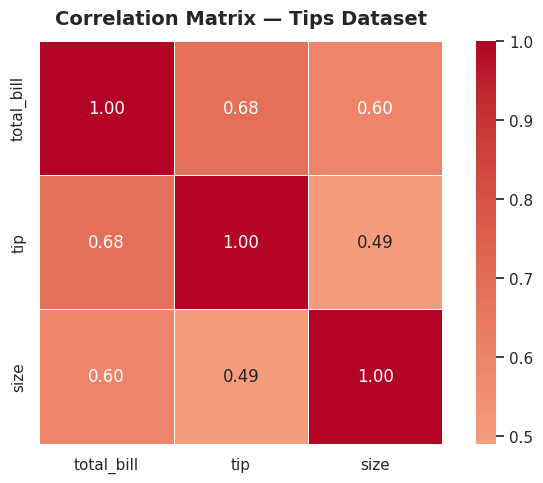

In [30]:
# ── Correlation Analysis ────────────────────────────────────
corr = df.corr(numeric_only=True).round(2)
print('Correlation matrix:')
print(corr)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Tips Dataset', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 9. Visualization — Matplotlib & Seaborn

| Library | Best For |
|---------|----------|
| **Matplotlib** | Full control, custom layouts, publication-quality output |
| **Seaborn** | Statistical plots with minimal code, works directly with DataFrames |

> 💡 Use them together — create with seaborn, tweak with matplotlib.

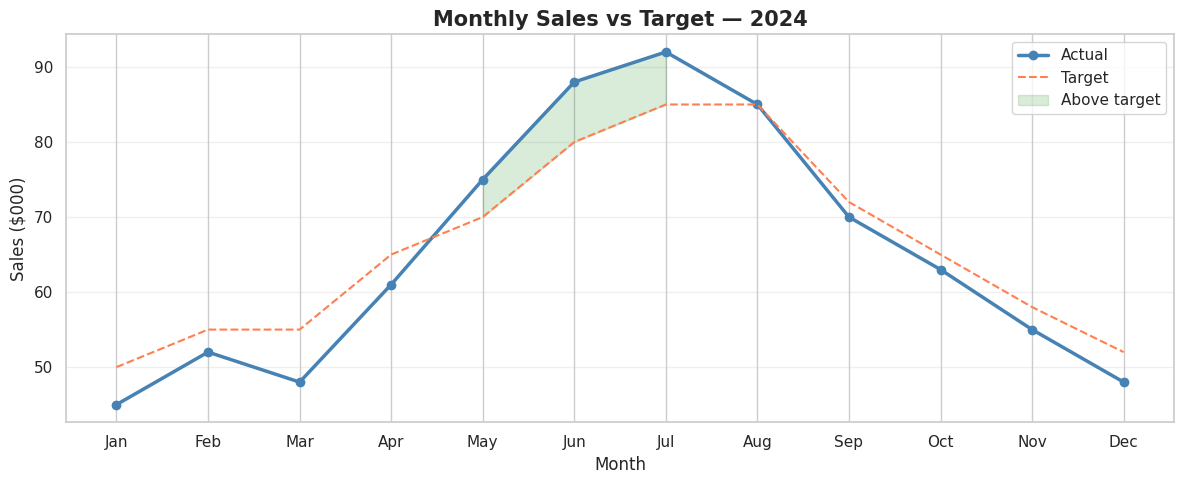

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ── Line Chart ──────────────────────────────────────────────
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sales  = [45, 52, 48, 61, 75, 88, 92, 85, 70, 63, 55, 48]
target = [50, 55, 55, 65, 70, 80, 85, 85, 72, 65, 58, 52]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(months, sales,  color='steelblue', linewidth=2.5, marker='o', markersize=6, label='Actual')
ax.plot(months, target, color='coral',     linewidth=1.5, linestyle='--', label='Target')
ax.fill_between(months, sales, target,
                where=[s > t for s, t in zip(sales, target)],
                alpha=0.15, color='green', label='Above target')

ax.set_title('Monthly Sales vs Target — 2024', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($000)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

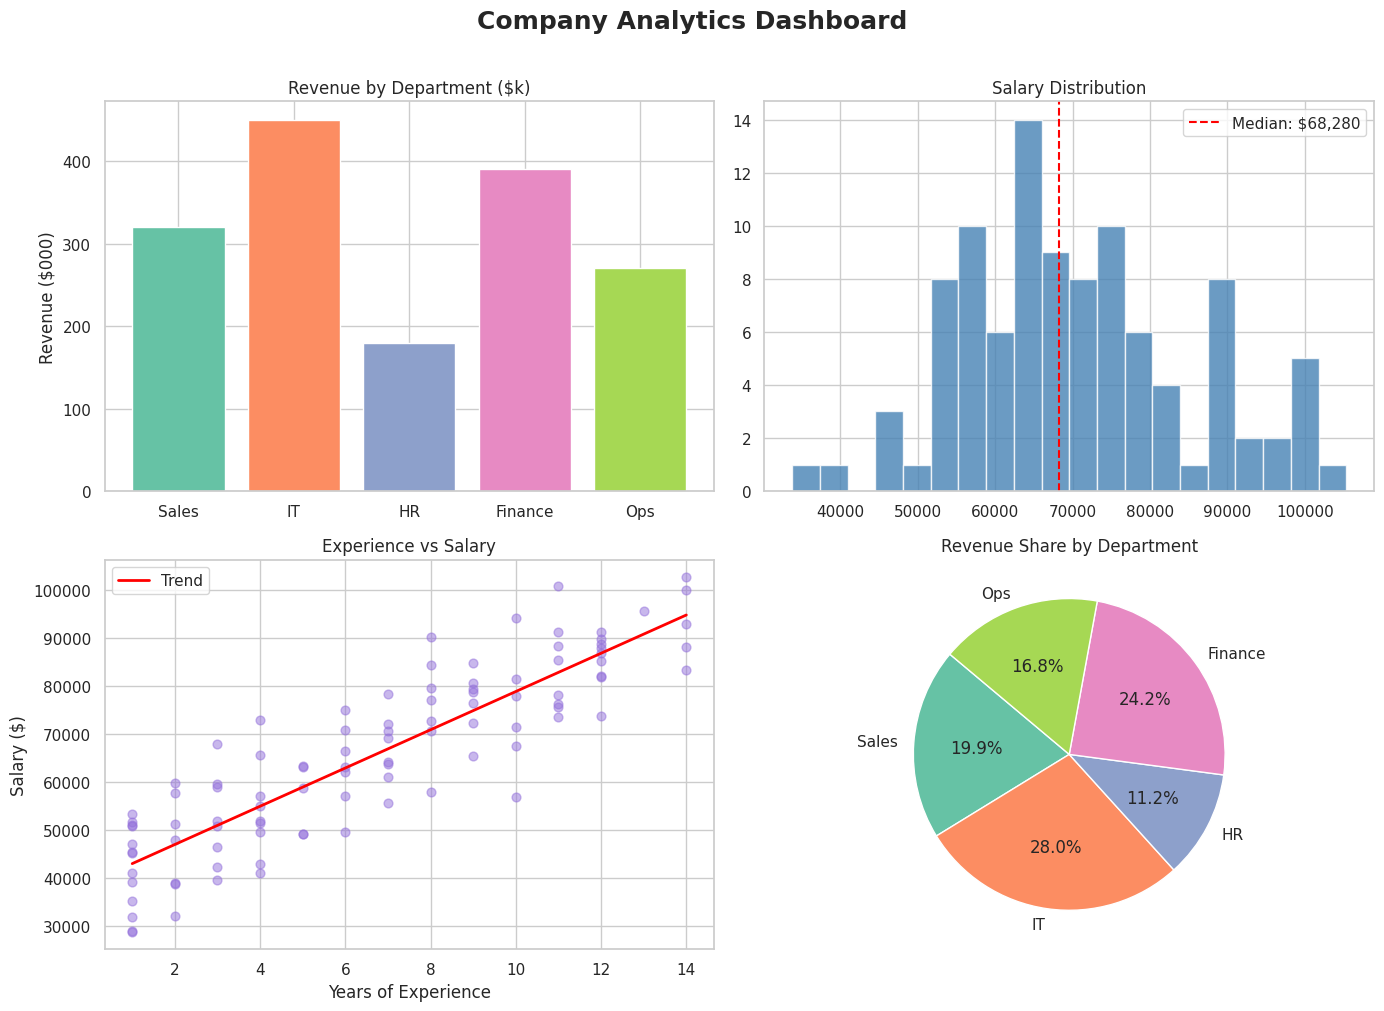

In [32]:
# ── 4-Panel Dashboard ──────────────────────────────────────
np.random.seed(42)
dept_names   = ['Sales', 'IT', 'HR', 'Finance', 'Ops']
dept_revenue = [320, 450, 180, 390, 270]
salaries_all = np.concatenate([
    np.random.normal(70000, 12000, 40),
    np.random.normal(85000, 15000, 30),
    np.random.normal(60000, 10000, 30)
])
exp = np.random.randint(1, 15, 100)
sal = 40000 + exp * 4000 + np.random.normal(0, 8000, 100)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Company Analytics Dashboard', fontsize=18, fontweight='bold', y=1.01)

# 1. Bar chart
axes[0,0].bar(dept_names, dept_revenue, color=sns.color_palette('Set2'))
axes[0,0].set_title('Revenue by Department ($k)')
axes[0,0].set_ylabel('Revenue ($000)')

# 2. Histogram
axes[0,1].hist(salaries_all, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].axvline(np.median(salaries_all), color='red', linestyle='--', label=f'Median: ${np.median(salaries_all):,.0f}')
axes[0,1].set_title('Salary Distribution')
axes[0,1].legend()

# 3. Scatter
axes[1,0].scatter(exp, sal, alpha=0.5, color='mediumpurple', s=40)
m, b = np.polyfit(exp, sal, 1)
axes[1,0].plot(sorted(exp), m*np.array(sorted(exp))+b, color='red', linewidth=2, label='Trend')
axes[1,0].set_title('Experience vs Salary')
axes[1,0].set_xlabel('Years of Experience')
axes[1,0].set_ylabel('Salary ($)')
axes[1,0].legend()

# 4. Pie chart
axes[1,1].pie(dept_revenue, labels=dept_names, autopct='%1.1f%%',
              colors=sns.color_palette('Set2'), startangle=140)
axes[1,1].set_title('Revenue Share by Department')

plt.tight_layout()
plt.show()

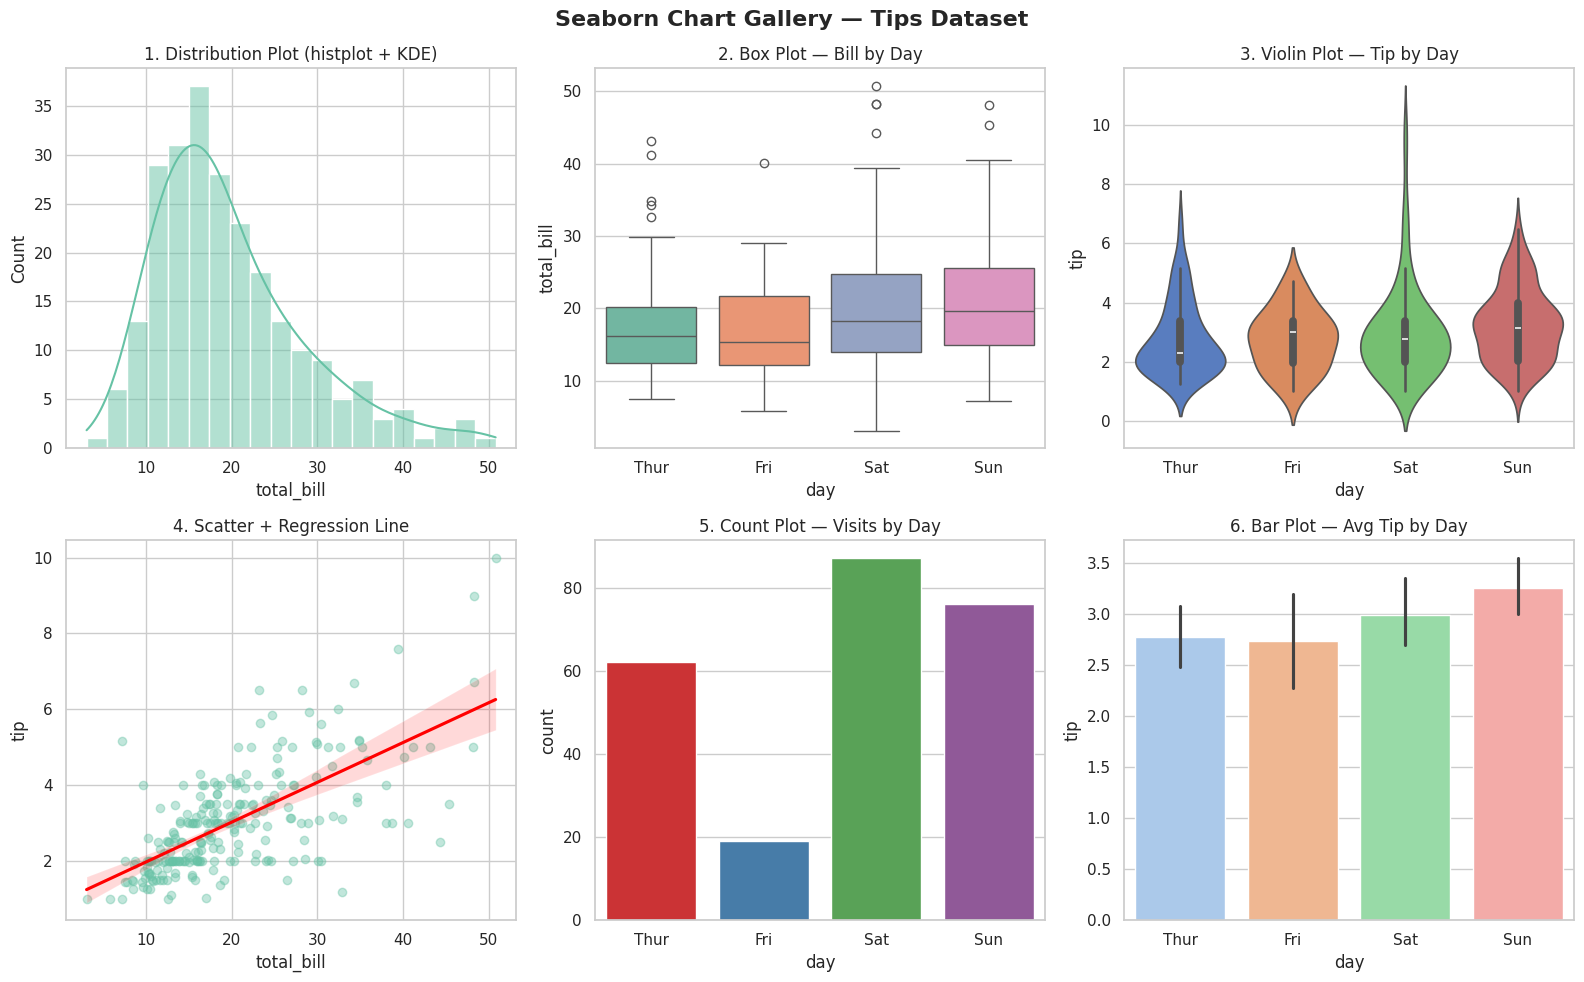

In [33]:
# ── Seaborn Gallery ─────────────────────────────────────────
tips = sns.load_dataset('tips')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Seaborn Chart Gallery — Tips Dataset', fontsize=16, fontweight='bold')

# 1. Distribution
sns.histplot(tips['total_bill'], kde=True, bins=20, ax=axes[0,0])
axes[0,0].set_title('1. Distribution Plot (histplot + KDE)')

# 2. Box plot
sns.boxplot(data=tips, x='day', y='total_bill', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('2. Box Plot — Bill by Day')

# 3. Violin plot
sns.violinplot(data=tips, x='day', y='tip', palette='muted', ax=axes[0,2])
axes[0,2].set_title('3. Violin Plot — Tip by Day')

# 4. Scatter with regression
sns.regplot(data=tips, x='total_bill', y='tip',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=axes[1,0])
axes[1,0].set_title('4. Scatter + Regression Line')

# 5. Count plot
sns.countplot(data=tips, x='day', order=['Thur','Fri','Sat','Sun'],
              palette='Set1', ax=axes[1,1])
axes[1,1].set_title('5. Count Plot — Visits by Day')

# 6. Bar plot (mean + CI)
sns.barplot(data=tips, x='day', y='tip', estimator='mean',
            order=['Thur','Fri','Sat','Sun'], palette='pastel', ax=axes[1,2])
axes[1,2].set_title('6. Bar Plot — Avg Tip by Day')

plt.tight_layout()
plt.show()

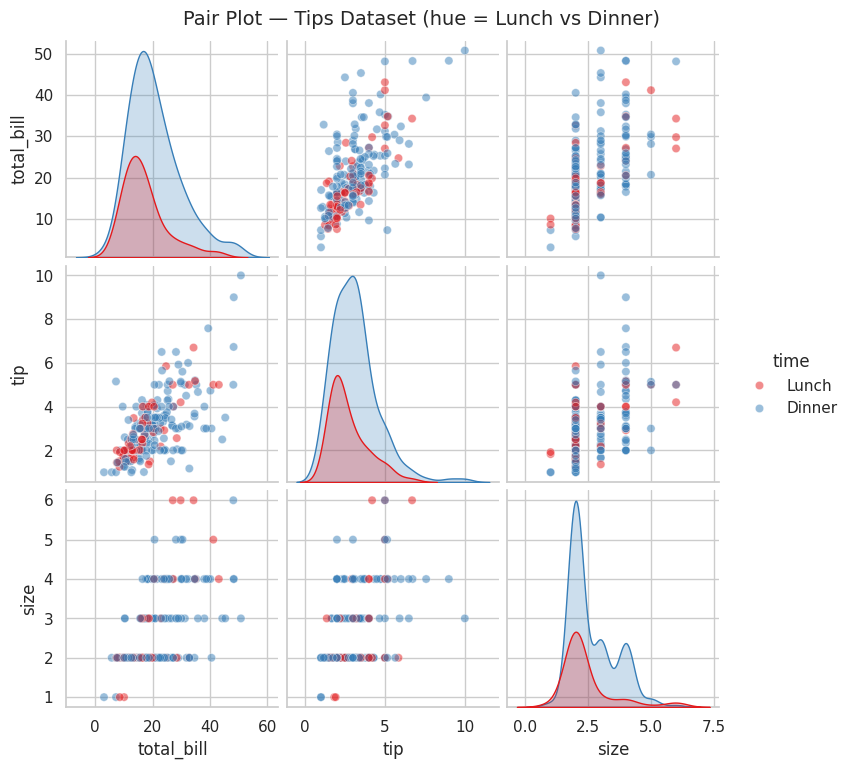

In [34]:
# ── Pair Plot — all variables vs all variables ──────────────
# Great for initial EDA on a new numeric dataset
g = sns.pairplot(tips, hue='time', diag_kind='kde',
                 plot_kws={'alpha': 0.5}, palette='Set1')
g.fig.suptitle('Pair Plot — Tips Dataset (hue = Lunch vs Dinner)', y=1.02, fontsize=14)
plt.show()

---
## 10. Basic Statistics
You don't need to be a statistician, but you need to understand these core concepts
well enough to **interpret your own analysis and communicate results correctly**.

Salary data: [55000, 62000, 69000, 75000, 82000, 91000, 250000]

Mean:   $97,714   ← pulled up by the $250k outlier
Median: $75,000   ← represents a "typical" employee better
Std Dev: $68,220


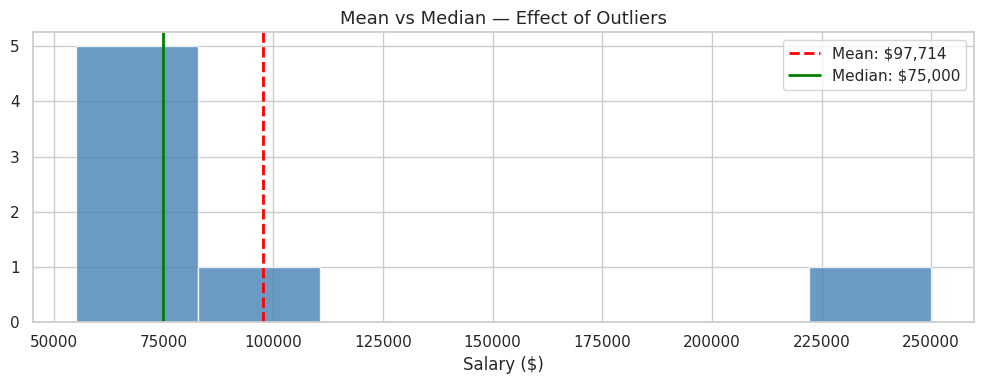

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset with an outlier to illustrate mean vs median
salaries = pd.Series([55000, 62000, 69000, 75000, 82000, 91000, 250000])

mean_val   = salaries.mean()
median_val = salaries.median()

print('Salary data:', salaries.tolist())
print(f'\nMean:   ${mean_val:,.0f}   ← pulled up by the $250k outlier')
print(f'Median: ${median_val:,.0f}   ← represents a "typical" employee better')
print(f'Std Dev: ${salaries.std():,.0f}')

# Visualize the difference
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(salaries, bins=7, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(mean_val,   color='red',   linestyle='--', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
ax.axvline(median_val, color='green', linestyle='-',  linewidth=2, label=f'Median: ${median_val:,.0f}')
ax.set_title('Mean vs Median — Effect of Outliers', fontsize=13)
ax.set_xlabel('Salary ($)')
ax.legend()
plt.tight_layout()
plt.show()

Total records: 100
IQR outliers (42,387 – 99,024): 5
Z-score outliers (|z|>3): 4


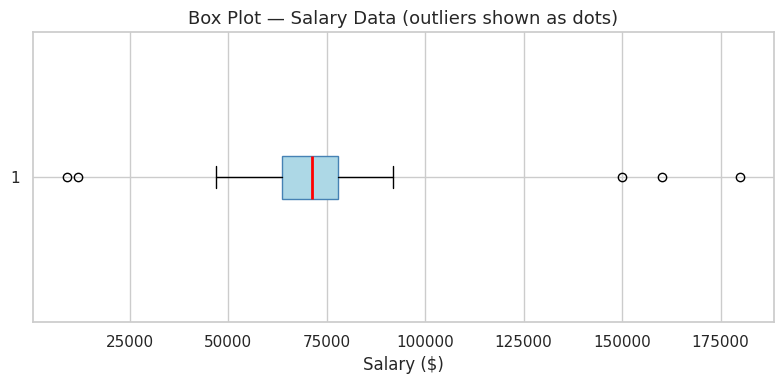

In [36]:
# ── Detecting Outliers ─────────────────────────────────────
import scipy.stats as stats

np.random.seed(1)
data = pd.Series(list(np.random.normal(70000, 10000, 95)) + [150000, 160000, 180000, 12000, 9000])

# Method 1: IQR Method (recommended for skewed data)
Q1  = data.quantile(0.25)
Q3  = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
iqr_outliers = data[(data < lower) | (data > upper)]

# Method 2: Z-Score (assumes normal distribution)
z_scores = np.abs(stats.zscore(data))
z_outliers = data[z_scores > 3]

print(f'Total records: {len(data)}')
print(f'IQR outliers ({lower:,.0f} – {upper:,.0f}): {len(iqr_outliers)}')
print(f'Z-score outliers (|z|>3): {len(z_outliers)}')

# Box plot to visualize
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Box Plot — Salary Data (outliers shown as dots)', fontsize=13)
ax.set_xlabel('Salary ($)')
plt.tight_layout()
plt.show()

Correlation (r) = 0.939
r² = 0.882  → experience explains 88.2% of salary variance
Interpretation: Strong positive correlation
⚠️  BUT: correlation does not prove causation!
   Many other variables (role, company, location) also influence salary.


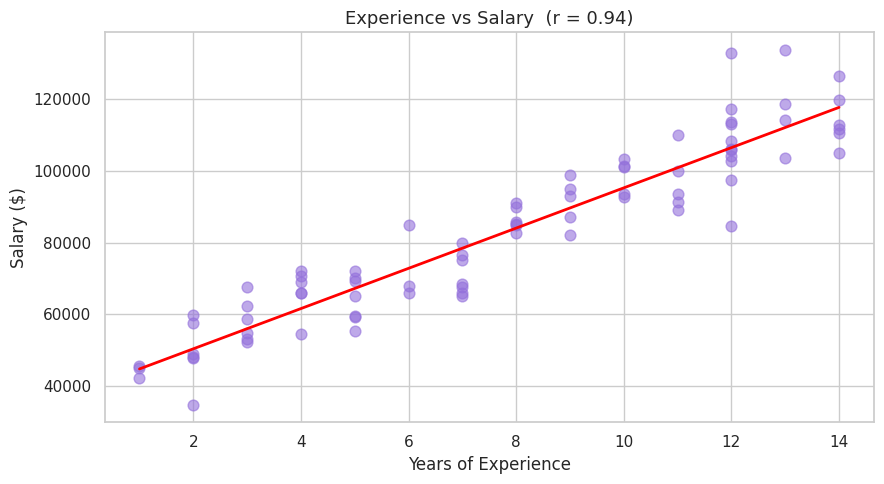

In [37]:
# ── Correlation vs Causation ────────────────────────────────
np.random.seed(42)
experience = np.random.randint(1, 15, 80)
salary     = 40000 + experience * 5500 + np.random.normal(0, 8000, 80)

# Calculate Pearson correlation
r = np.corrcoef(experience, salary)[0, 1]
print(f'Correlation (r) = {r:.3f}')
print(f'r² = {r**2:.3f}  → experience explains {r**2*100:.1f}% of salary variance')

if abs(r) >= 0.7:
    strength = 'Strong'
elif abs(r) >= 0.4:
    strength = 'Moderate'
else:
    strength = 'Weak'
print(f'Interpretation: {strength} positive correlation')
print('⚠️  BUT: correlation does not prove causation!')
print('   Many other variables (role, company, location) also influence salary.')

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(experience, salary, alpha=0.6, color='mediumpurple', s=60)
m, b = np.polyfit(experience, salary, 1)
ax.plot(sorted(experience), m*np.array(sorted(experience))+b, color='red', linewidth=2)
ax.set_title(f'Experience vs Salary  (r = {r:.2f})', fontsize=13)
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Salary ($)')
plt.tight_layout()
plt.show()